# TabPFN Aircraft Corrosion Risk Prediction
## With Corrosion Exposure Indices

This notebook implements corrosion risk prediction using TabPFN with custom corrosion exposure features.

**New Features:**
- `corrosion_exposure_index`: Combines SO2 + NO2 with humidity and parking time
- `moisture_exposure_index`: Humidity × parking time exposure

## 1. Setup and Installation

In [1]:
# Install required packages
!pip install -q tabpfn scikit-learn pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.2/753.2 kB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.8/270.8 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, brier_score_loss, average_precision_score
from sklearn.preprocessing import RobustScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("✓ Imports successful")

✓ Imports successful


## 2. Upload Data Files

Upload the following files from your local machine:
- `corrosions_training.csv`
- `environment_training.csv`

In [3]:
# For Google Colab
from google.colab import files

print("Upload corrosions_training.csv:")
uploaded = files.upload()

print("\nUpload environment_training.csv:")
uploaded = files.upload()

print("\n✓ Files uploaded successfully")

Upload corrosions_training.csv:


Saving corrosions_training.csv to corrosions_training.csv

Upload environment_training.csv:


Saving environment_training.csv to environment_training.csv

✓ Files uploaded successfully


## 3. Load and Prepare Data

In [4]:
# Load corrosion data
print("Loading corrosion data...")
corr_df = pd.read_csv('corrosions_training.csv', parse_dates=['observation_date'])

# Calculate months since delivery
corr_df['months_since_delivery'] = (
    (corr_df['observation_date'].dt.year - corr_df['aircraft_delivery_year']) * 12 +
    (corr_df['observation_date'].dt.month - corr_df['aircraft_delivery_month'])
)

print(f"Corrosion data: {corr_df.shape}")
print(f"Aircraft: {corr_df['aircraft_id'].nunique()}")
print(f"Months range: {corr_df['months_since_delivery'].min():.0f} - {corr_df['months_since_delivery'].max():.0f}")

corr_df.head()

Loading corrosion data...
Corrosion data: (790, 5)
Aircraft: 790
Months range: 5 - 136


,observation_date,aircraft_delivery_year,aircraft_delivery_month,aircraft_id,months_since_delivery
0,2021-11-11,2015,11,952a92,72
1,2021-12-21,2015,12,9a0b74,72
2,2022-06-01,2017,2,11725a,64
3,2019-11-05,2016,1,e8929a,46
4,2024-10-10,2018,10,f7835d,72


In [5]:
# Load environment data
print("Loading environment data...")
env_df = pd.read_csv('environment_training.csv')

print(f"Environment data: {env_df.shape}")
print(f"\nAvailable features: {len(env_df.columns)}")

env_df.head()

Loading environment data...
Environment data: (63524, 36)

Available features: 36


,aircraft_id,year_month,month_start_date,total_parking_minutes,metar_temperature_c,metar_relative_humidity,metar_dew_point_c,metar_wind_speed_kn,metar_visibility_mi,metar_hour_precipitation,...,h2o2,formaldehyde,hno3,nitrogen_monoxide_mass_mixing_ratio,nitrogen_dioxide_mass_mixing_ratio,oh,organic_nitrates,specific_humidity,sulphur_dioxide_mass_mixing_ratio,temperature
0,a414b2,2017-04,2017-04-01T00:00:00Z,41220.150000,30.718293,30.899519,9.558831,5.710531,2.196935,0.0,...,1.391024e-09,5.049084e-09,5.711211e-09,2.694732e-08,3.239839e-08,9.621187e-14,1.688966e-09,0.007535,5.227935e-08,302.226554
1,a414b2,2021-07,2021-07-01T00:00:00Z,28587.733333,29.397745,78.179996,24.765060,6.290009,2.414297,0.0,...,1.169712e-09,2.717347e-09,2.222564e-09,6.977001e-09,1.693530e-08,6.740166e-14,8.613307e-10,0.018132,1.506060e-08,301.692884
2,41ef34,2024-01,2024-01-01T00:00:00Z,29868.166667,15.522649,76.737610,10.499426,3.765631,1.029053,0.0,...,7.315543e-10,5.885936e-09,4.869761e-09,2.471157e-08,4.266760e-08,2.792927e-14,7.472720e-09,0.008187,5.721327e-08,287.567593
3,e2d345,2019-05,2019-05-01T00:00:00Z,18139.383333,30.951416,42.349314,15.166188,7.073745,5.594613,0.0,...,2.941217e-09,2.050597e-08,1.112867e-08,8.965584e-10,4.222114e-08,1.126736e-13,2.468868e-08,0.014630,1.843788e-08,301.816769
4,cfa8ab,2025-07,2025-07-01T00:00:00Z,26916.333333,27.367780,81.524175,23.630275,7.467336,2.774049,0.0,...,8.699552e-10,3.026269e-09,2.116588e-09,4.818643e-09,1.728175e-08,7.366147e-14,1.265471e-09,0.018309,1.331511e-08,299.727528


## 4. Calculate Corrosion Exposure Indices

In [6]:
# Calculate corrosion exposure indices
print("Calculating corrosion exposure indices...")

# Corrosion exposure index: (SO2 + NO2) × humidity × parking_time
env_df['corrosion_exposure_index'] = (
    (env_df['sulphur_dioxide_mass_mixing_ratio'] +
     env_df['nitrogen_dioxide_mass_mixing_ratio']) *
    env_df['metar_relative_humidity'] *
    env_df['total_parking_minutes'] / 1000
)

# Moisture exposure index: humidity × parking_time
env_df['moisture_exposure_index'] = (
    env_df['metar_relative_humidity'] *
    env_df['total_parking_minutes'] / 100
)

print(f"\nCorrosion exposure index:")
print(f"  Min: {env_df['corrosion_exposure_index'].min():.6f}")
print(f"  Max: {env_df['corrosion_exposure_index'].max():.6f}")
print(f"  Mean: {env_df['corrosion_exposure_index'].mean():.6f}")

print(f"\nMoisture exposure index:")
print(f"  Min: {env_df['moisture_exposure_index'].min():.2f}")
print(f"  Max: {env_df['moisture_exposure_index'].max():.2f}")
print(f"  Mean: {env_df['moisture_exposure_index'].mean():.2f}")

Calculating corrosion exposure indices...

Corrosion exposure index:
  Min: 0.000000
  Max: 0.001934
  Mean: 0.000051

Moisture exposure index:
  Min: 0.36
  Max: 42068.43
  Mean: 20799.48


## 5. Aggregate Features per Aircraft

In [7]:
# Select key environmental features
env_features = [
    'metar_relative_humidity',
    'metar_temperature_c',
    'total_parking_minutes',
    'sulphur_dioxide_mass_mixing_ratio',
    'nitrogen_dioxide_mass_mixing_ratio',
    'corrosion_exposure_index',
    'moisture_exposure_index'
]

# Aggregate per aircraft
print("Aggregating features per aircraft...")
agg_dict = {}
for feat in env_features:
    agg_dict[f"{feat}__mean"] = (feat, 'mean')
    agg_dict[f"{feat}__std"] = (feat, 'std')

env_agg = env_df.groupby('aircraft_id').agg(**agg_dict).reset_index()
env_agg = env_agg.fillna(0)

print(f"Aggregated features: {env_agg.shape}")
env_agg.head()

Aggregating features per aircraft...
Aggregated features: (758, 15)


,aircraft_id,metar_relative_humidity__mean,metar_relative_humidity__std,metar_temperature_c__mean,metar_temperature_c__std,total_parking_minutes__mean,total_parking_minutes__std,sulphur_dioxide_mass_mixing_ratio__mean,sulphur_dioxide_mass_mixing_ratio__std,nitrogen_dioxide_mass_mixing_ratio__mean,nitrogen_dioxide_mass_mixing_ratio__std,corrosion_exposure_index__mean,corrosion_exposure_index__std,moisture_exposure_index__mean,moisture_exposure_index__std
0,002eab,66.942422,10.202324,21.396885,4.371590,28008.524306,9462.506250,8.965124e-09,1.999512e-08,1.020477e-08,2.801042e-09,0.000034,0.000030,19314.095082,8603.487516
1,009e95,72.978200,4.601319,16.829972,5.375780,33918.340000,7570.435859,2.659692e-09,1.431814e-09,7.943512e-09,4.066848e-09,0.000027,0.000018,24709.391400,5597.356753
2,01c05c,73.986732,10.920739,19.888205,5.405923,33262.248958,7757.813583,6.162789e-09,3.566311e-09,9.839522e-09,2.886665e-09,0.000038,0.000015,24675.888777,7438.484060
3,02884d,74.516124,5.571566,18.279174,5.307860,29629.682386,7153.844406,2.264604e-09,6.868170e-10,4.418345e-09,2.129540e-09,0.000015,0.000007,22031.646717,5412.015568
4,02d1d2,79.075717,4.076926,15.642075,3.453714,31482.290506,6771.522360,1.500775e-09,1.247545e-09,3.752023e-09,1.736488e-09,0.000012,0.000006,24910.712970,5498.280162


## 6. Create Training Pairs (Airbus Convention)

In [8]:
# Create training pairs
print("Creating training pairs...")

# Filter aircraft with sufficient observation time
valid_aircraft = corr_df[corr_df['months_since_delivery'] >= 24].copy()
print(f"Aircraft with observation >= 24 months: {len(valid_aircraft)}")

pairs = []
for _, row in valid_aircraft.iterrows():
    aircraft_id = row['aircraft_id']
    obs_month = row['months_since_delivery']

    # Get environmental features
    env_features = env_agg[env_agg['aircraft_id'] == aircraft_id]
    if env_features.empty:
        continue
    env_features = env_features.iloc[0].to_dict()

    # Pair 1: Corroded state (observation month)
    pair_1 = {
        'aircraft_id': aircraft_id,
        'reference_month': obs_month,
        'corrosion_risk': 1,
        **{k: v for k, v in env_features.items() if k != 'aircraft_id'}
    }
    pairs.append(pair_1)

    # Pair 2: Healthy state (24 months before)
    pair_0 = {
        'aircraft_id': aircraft_id,
        'reference_month': obs_month - 24,
        'corrosion_risk': 0,
        **{k: v for k, v in env_features.items() if k != 'aircraft_id'}
    }
    pairs.append(pair_0)

pairs_df = pd.DataFrame(pairs)

print(f"\nCreated {len(pairs_df)} training samples ({len(pairs_df)//2} aircraft pairs)")
print(f"  - corrosion_risk=1: {(pairs_df['corrosion_risk']==1).sum()}")
print(f"  - corrosion_risk=0: {(pairs_df['corrosion_risk']==0).sum()}")

pairs_df.head()

Creating training pairs...
Aircraft with observation >= 24 months: 759

Created 1460 training samples (730 aircraft pairs)
  - corrosion_risk=1: 730
  - corrosion_risk=0: 730


,aircraft_id,reference_month,corrosion_risk,metar_relative_humidity__mean,metar_relative_humidity__std,metar_temperature_c__mean,metar_temperature_c__std,total_parking_minutes__mean,total_parking_minutes__std,sulphur_dioxide_mass_mixing_ratio__mean,sulphur_dioxide_mass_mixing_ratio__std,nitrogen_dioxide_mass_mixing_ratio__mean,nitrogen_dioxide_mass_mixing_ratio__std,corrosion_exposure_index__mean,corrosion_exposure_index__std,moisture_exposure_index__mean,moisture_exposure_index__std
0,952a92,72,1,29.952276,15.909522,8.021682,4.799892,25790.205698,5432.818437,4.774585e-09,1.258249e-09,1.032187e-08,2.278399e-09,0.000012,0.000008,8060.904730,5941.336974
1,952a92,48,0,29.952276,15.909522,8.021682,4.799892,25790.205698,5432.818437,4.774585e-09,1.258249e-09,1.032187e-08,2.278399e-09,0.000012,0.000008,8060.904730,5941.336974
2,9a0b74,72,1,73.537943,8.688555,14.263424,6.196463,31410.310700,5458.577588,1.959127e-09,9.974229e-10,1.001653e-08,4.065068e-09,0.000028,0.000015,23195.284728,5352.240810
3,9a0b74,48,0,73.537943,8.688555,14.263424,6.196463,31410.310700,5458.577588,1.959127e-09,9.974229e-10,1.001653e-08,4.065068e-09,0.000028,0.000015,23195.284728,5352.240810
4,11725a,64,1,78.935093,6.459029,27.844369,1.452420,33157.338072,11434.064342,1.146045e-08,4.329215e-09,9.081646e-09,3.521970e-09,0.000051,0.000017,26338.227067,9765.001355


## 7. Visualize Feature Distributions

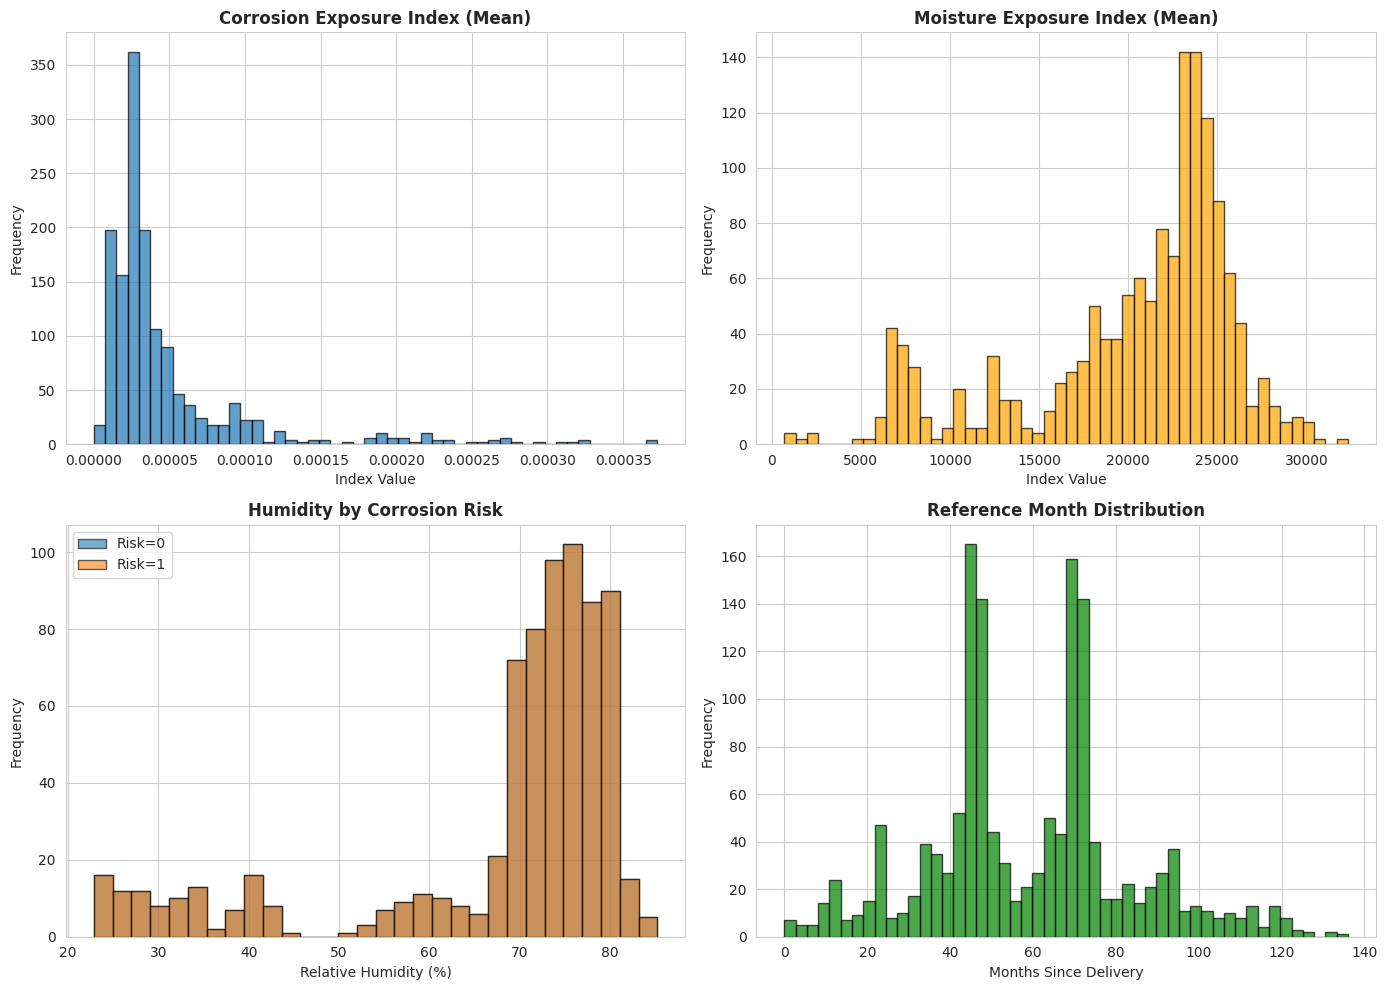

In [9]:
# Plot feature distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Corrosion exposure index
axes[0, 0].hist(pairs_df['corrosion_exposure_index__mean'], bins=50, alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Corrosion Exposure Index (Mean)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Index Value')
axes[0, 0].set_ylabel('Frequency')

# Moisture exposure index
axes[0, 1].hist(pairs_df['moisture_exposure_index__mean'], bins=50, alpha=0.7, edgecolor='black', color='orange')
axes[0, 1].set_title('Moisture Exposure Index (Mean)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Index Value')
axes[0, 1].set_ylabel('Frequency')

# Humidity by corrosion risk
for risk in [0, 1]:
    data = pairs_df[pairs_df['corrosion_risk'] == risk]['metar_relative_humidity__mean']
    axes[1, 0].hist(data, bins=30, alpha=0.6, label=f'Risk={risk}', edgecolor='black')
axes[1, 0].set_title('Humidity by Corrosion Risk', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Relative Humidity (%)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# Reference month distribution
axes[1, 1].hist(pairs_df['reference_month'], bins=50, alpha=0.7, edgecolor='black', color='green')
axes[1, 1].set_title('Reference Month Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Months Since Delivery')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 8. Train TabPFN Model with Cross-Validation

In [10]:
# Prepare features
feature_cols = ['reference_month'] + [c for c in pairs_df.columns if '__' in c and c != 'aircraft_id']
X = pairs_df[feature_cols].values
y = pairs_df['corrosion_risk'].values
groups = pairs_df['aircraft_id'].values

print(f"Features: {len(feature_cols)}")
print(f"Samples: {len(X)}")
print(f"\nFeature list:")
for i, feat in enumerate(feature_cols, 1):
    print(f"  {i}. {feat}")

Features: 15
Samples: 1460

Feature list:
  1. reference_month
  2. metar_relative_humidity__mean
  3. metar_relative_humidity__std
  4. metar_temperature_c__mean
  5. metar_temperature_c__std
  6. total_parking_minutes__mean
  7. total_parking_minutes__std
  8. sulphur_dioxide_mass_mixing_ratio__mean
  9. sulphur_dioxide_mass_mixing_ratio__std
  10. nitrogen_dioxide_mass_mixing_ratio__mean
  11. nitrogen_dioxide_mass_mixing_ratio__std
  12. corrosion_exposure_index__mean
  13. corrosion_exposure_index__std
  14. moisture_exposure_index__mean
  15. moisture_exposure_index__std


In [11]:
# Check TabPFN availability
try:
    from tabpfn import TabPFNClassifier
    import os
    os.environ["TABPFN_TOKEN"] = "tabpfn_sk_M6ludu20Be9kVMWaGFmJ2UWgHNwwPQ-gqOGXSXf15fc"
    print("✓ TabPFN available")
    use_tabpfn = True
except ImportError:
    print("⚠ TabPFN not available, using GradientBoosting fallback")
    from sklearn.ensemble import GradientBoostingClassifier
    use_tabpfn = False

✓ TabPFN available


In [13]:
# Cross-validation
from sklearn.model_selection import StratifiedGroupKFold

n_splits = 5
splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)

aucs = []
briers = []
aps = []

print(f"Running {n_splits}-fold cross-validation...\n")

for fold, (train_idx, test_idx) in enumerate(splitter.split(X, y, groups), 1):
    print(f"Fold {fold}/{n_splits}...", end=" ")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Scale features
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train model
    if use_tabpfn:
        base_model = TabPFNClassifier(device='cuda')
    else:
        base_model = GradientBoostingClassifier(
            random_state=42,
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05
        )

    # Calibrate
    model = CalibratedClassifierCV(base_model, method='isotonic', cv=3)
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    auc = roc_auc_score(y_test, y_pred)
    brier = brier_score_loss(y_test, y_pred)
    ap = average_precision_score(y_test, y_pred)

    aucs.append(auc)
    briers.append(brier)
    aps.append(ap)

    print(f"AUC={auc:.4f}, Brier={brier:.4f}, AP={ap:.4f}")

print(f"\n{'='*60}")
print("CROSS-VALIDATION RESULTS:")
print(f"{'='*60}")
print(f"AUC:            {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
print(f"Brier Score:    {np.mean(briers):.4f} ± {np.std(briers):.4f}")
print(f"Avg Precision:  {np.mean(aps):.4f} ± {np.std(aps):.4f}")
print(f"{'='*60}")

Running 5-fold cross-validation...

Fold 1/5... AUC=0.8818, Brier=0.1384, AP=0.8749
Fold 2/5... AUC=0.8800, Brier=0.1395, AP=0.8870
Fold 3/5... AUC=0.9158, Brier=0.1170, AP=0.9024
Fold 4/5... AUC=0.8763, Brier=0.1412, AP=0.8827
Fold 5/5... AUC=0.9024, Brier=0.1255, AP=0.8994

CROSS-VALIDATION RESULTS:
AUC:            0.8912 ± 0.0153
Brier Score:    0.1323 ± 0.0095
Avg Precision:  0.8893 ± 0.0103


## 9. Feature Importance Analysis

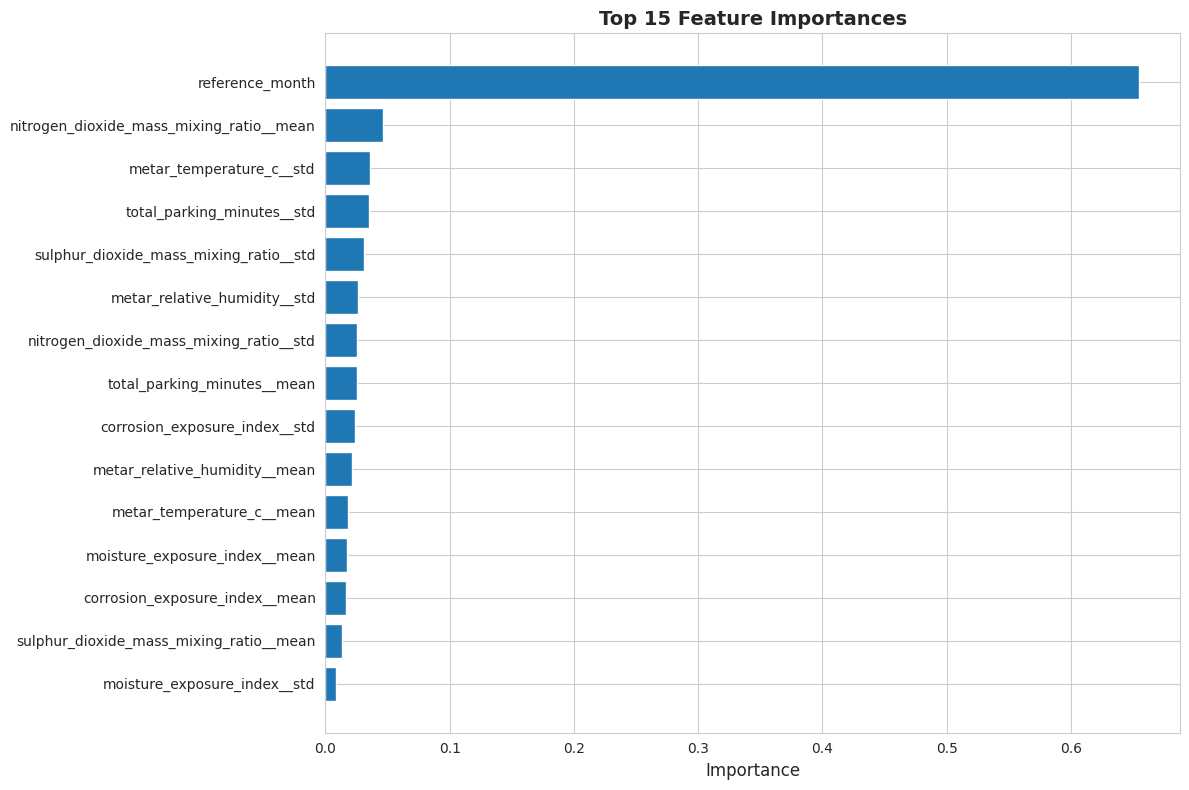


Top 10 Features:
                                 feature  importance
                         reference_month    0.654981
nitrogen_dioxide_mass_mixing_ratio__mean    0.046236
                metar_temperature_c__std    0.035820
              total_parking_minutes__std    0.034923
  sulphur_dioxide_mass_mixing_ratio__std    0.031200
            metar_relative_humidity__std    0.026311
 nitrogen_dioxide_mass_mixing_ratio__std    0.025310
             total_parking_minutes__mean    0.025143
           corrosion_exposure_index__std    0.023428
           metar_relative_humidity__mean    0.021571


In [14]:
# Train final model for feature importance
from sklearn.ensemble import GradientBoostingClassifier

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

model = GradientBoostingClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05
)
model.fit(X_scaled, y)

# Get feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot
plt.figure(figsize=(12, 8))
plt.barh(importance_df['feature'][:15], importance_df['importance'][:15])
plt.xlabel('Importance', fontsize=12)
plt.title('Top 15 Feature Importances', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
print(importance_df.head(10).to_string(index=False))

## 10. Summary and Conclusions

In [15]:
print("="*60)
print("SUMMARY")
print("="*60)
print(f"\n✓ Dataset: {len(pairs_df)} samples from {len(valid_aircraft)} aircraft")
print(f"✓ Features: {len(feature_cols)} (including 2 new corrosion indices)")
print(f"\n✓ New Features:")
print(f"  - corrosion_exposure_index: (SO2 + NO2) × humidity × parking_time")
print(f"  - moisture_exposure_index: humidity × parking_time")
print(f"\n✓ Model Performance:")
print(f"  - AUC: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
print(f"  - Brier Score: {np.mean(briers):.4f} ± {np.std(briers):.4f}")
print(f"  - Average Precision: {np.mean(aps):.4f} ± {np.std(aps):.4f}")
print(f"\n✓ Model: {'TabPFN' if use_tabpfn else 'GradientBoosting'} with isotonic calibration")
print("="*60)

SUMMARY

✓ Dataset: 1460 samples from 759 aircraft
✓ Features: 15 (including 2 new corrosion indices)

✓ New Features:
  - corrosion_exposure_index: (SO2 + NO2) × humidity × parking_time
  - moisture_exposure_index: humidity × parking_time

✓ Model Performance:
  - AUC: 0.8912 ± 0.0153
  - Brier Score: 0.1323 ± 0.0095
  - Average Precision: 0.8893 ± 0.0103

✓ Model: TabPFN with isotonic calibration


# 11. Inference

In [17]:
# Upload environment_test.csv
print("Upload environment_test.csv:")
uploaded = files.upload()

print("\n✓ Test file uploaded successfully")

Upload environment_test.csv:


Saving environment_test.csv to environment_test.csv

✓ Test file uploaded successfully


In [28]:
# Load test environment data
print("Loading test environment data...")
env_test_df = pd.read_csv('environment_test.csv')
env_test_df['month_start_date'] = pd.to_datetime(env_test_df['month_start_date'])

print(f"Test environment data: {env_test_df.shape}")
print(f"Test aircraft: {env_test_df['aircraft_id'].nunique()}")
print(f"Total rows (predictions to generate): {len(env_test_df)}")

env_test_df.head()

Loading test environment data...
Test environment data: (14303, 36)
Test aircraft: 142
Total rows (predictions to generate): 14303


,aircraft_id,year_month,month_start_date,total_parking_minutes,metar_temperature_c,metar_relative_humidity,metar_dew_point_c,metar_wind_speed_kn,metar_visibility_mi,metar_hour_precipitation,...,h2o2,formaldehyde,hno3,nitrogen_monoxide_mass_mixing_ratio,nitrogen_dioxide_mass_mixing_ratio,oh,organic_nitrates,specific_humidity,sulphur_dioxide_mass_mixing_ratio,temperature
0,74b7d1,2020-01,2020-01-01 00:00:00+00:00,29661.266667,18.115760,64.794068,10.624052,6.081251,4.861379,0.0,...,1.219636e-09,1.103049e-08,4.355803e-09,2.648651e-09,2.779879e-08,5.336528e-14,7.891366e-09,0.008817,1.504748e-08,290.996197
1,1b9e65,2022-06,2022-06-01 00:00:00+00:00,28253.500000,27.917686,79.895719,23.923473,4.549184,5.697430,0.0,...,1.185155e-09,2.615746e-09,1.337685e-09,3.987852e-09,1.343797e-08,7.051002e-14,8.593372e-10,0.018658,8.229262e-09,299.937699
2,77e86b,2023-01,2023-01-01 00:00:00+00:00,20585.816667,17.355278,65.403761,10.211976,6.309417,5.313693,0.0,...,1.189618e-09,1.358332e-08,4.625051e-09,1.071706e-09,2.848547e-08,5.968779e-14,8.038602e-09,0.008156,1.358791e-08,291.151523
3,74b7d1,2020-02,2020-02-01 00:00:00+00:00,27193.016667,18.345141,59.096483,8.712455,6.146575,4.996108,0.0,...,1.393993e-09,1.274867e-08,5.633756e-09,1.431187e-09,3.205401e-08,6.171572e-14,1.519481e-08,0.008473,1.529476e-08,290.267892
4,8b98f3,2023-11,2023-11-01 00:00:00+00:00,29230.816667,4.358200,80.728763,0.981000,7.569466,4.215860,0.0,...,1.086793e-10,1.135113e-09,8.147228e-10,3.708668e-09,9.753847e-09,1.631353e-14,1.038825e-09,0.004514,8.297641e-09,277.452079


In [29]:
# Calculate corrosion exposure indices for test data
print("Calculating corrosion exposure indices for test data...")

# Corrosion exposure index
env_test_df['corrosion_exposure_index'] = (
    (env_test_df['sulphur_dioxide_mass_mixing_ratio'] +
     env_test_df['nitrogen_dioxide_mass_mixing_ratio']) *
    env_test_df['metar_relative_humidity'] *
    env_test_df['total_parking_minutes'] / 1000
)

# Moisture exposure index
env_test_df['moisture_exposure_index'] = (
    env_test_df['metar_relative_humidity'] *
    env_test_df['total_parking_minutes'] / 100
)

print("✓ Indices calculated")

Calculating corrosion exposure indices for test data...
✓ Indices calculated


In [30]:
# Aggregate test features per aircraft per month
print("Aggregating test features per aircraft-month...")

# Define the same features used in training
env_features = [
    'metar_relative_humidity',
    'metar_temperature_c',
    'metar_dew_point_c',
    'metar_wind_speed_kn',
    'sea_salt_aerosol_05_5_mixing_ratio',
    'sea_salt_aerosol_5_20_mixing_ratio',
    'ozone_mass_mixing_ratio',
    'sulphur_dioxide_mass_mixing_ratio',
    'nitrogen_dioxide_mass_mixing_ratio',
    'corrosion_exposure_index',
    'moisture_exposure_index'
]

# For each aircraft-month, compute mean of available features
test_agg = env_test_df.groupby(['aircraft_id', 'month_start_date'])[env_features].mean().reset_index()
test_agg = test_agg.fillna(0)

print(f"Aggregated test features: {test_agg.shape}")
print(f"Total predictions to generate: {len(test_agg)}")

test_agg.head()

# # Calculate corrosion exposure indices for test data
# print("Calculating corrosion exposure indices for test data...")

# # Corrosion exposure index
# env_test_df['corrosion_exposure_index'] = (
#     (env_test_df['sulphur_dioxide_mass_mixing_ratio'] +
#      env_test_df['nitrogen_dioxide_mass_mixing_ratio']) *
#     env_test_df['metar_relative_humidity'] *
#     env_test_df['total_parking_minutes'] / 1000
# )

# # Moisture exposure index
# env_test_df['moisture_exposure_index'] = (
#     env_test_df['metar_relative_humidity'] *
#     env_test_df['total_parking_minutes'] / 100
# )

# print("✓ Indices calculated")

Aggregating test features per aircraft-month...
Aggregated test features: (14303, 13)
Total predictions to generate: 14303


,aircraft_id,month_start_date,metar_relative_humidity,metar_temperature_c,metar_dew_point_c,metar_wind_speed_kn,sea_salt_aerosol_05_5_mixing_ratio,sea_salt_aerosol_5_20_mixing_ratio,ozone_mass_mixing_ratio,sulphur_dioxide_mass_mixing_ratio,nitrogen_dioxide_mass_mixing_ratio,corrosion_exposure_index,moisture_exposure_index
0,022433,2020-11-01 00:00:00+00:00,69.733472,27.414235,21.111754,7.375795,5.273335e-09,1.865253e-09,6.504233e-08,1.571157e-08,1.046022e-08,0.000008,3166.713187
1,022433,2020-12-01 00:00:00+00:00,69.511178,26.067300,19.728492,5.319701,2.024881e-09,7.498110e-10,5.388669e-08,2.796800e-08,1.893798e-08,0.000095,20273.421579
2,022433,2021-01-01 00:00:00+00:00,64.424554,25.506775,17.811324,5.461047,2.372974e-09,5.619119e-10,5.762102e-08,3.383723e-08,2.374943e-08,0.000136,23612.855485
3,022433,2021-02-01 00:00:00+00:00,66.988412,27.356447,20.006094,5.478113,3.457511e-09,4.133972e-10,5.696382e-08,2.860543e-08,2.147684e-08,0.000106,21214.403797
4,022433,2021-03-01 00:00:00+00:00,73.299731,29.168694,23.483972,6.799152,6.018679e-09,6.501350e-10,4.915828e-08,1.791335e-08,1.386809e-08,0.000070,22131.424456


In [31]:
# Calculate months since first observation for each aircraft
print("Calculating reference months...")

first_obs = env_test_df.groupby('aircraft_id')['month_start_date'].min().reset_index()
first_obs.columns = ['aircraft_id', 'first_observation_date']

test_agg = test_agg.merge(first_obs, on='aircraft_id', how='left')

# Calculate reference_month (months since first observation)
test_agg['reference_month'] = (
    (test_agg['month_start_date'].dt.year - test_agg['first_observation_date'].dt.year) * 12
    + (test_agg['month_start_date'].dt.month - test_agg['first_observation_date'].dt.month)
)

# Create id column in format: aircraft_id_YYYY-MM
test_agg['id'] = (
    test_agg['aircraft_id'] + '_' +
    test_agg['month_start_date'].dt.strftime('%Y-%m')
)

print(f"✓ Reference months calculated")
print(f"Reference month range: {test_agg['reference_month'].min():.0f} to {test_agg['reference_month'].max():.0f}")

test_agg.head()

Calculating reference months...
✓ Reference months calculated
Reference month range: 0 to 142


,aircraft_id,month_start_date,metar_relative_humidity,metar_temperature_c,metar_dew_point_c,metar_wind_speed_kn,sea_salt_aerosol_05_5_mixing_ratio,sea_salt_aerosol_5_20_mixing_ratio,ozone_mass_mixing_ratio,sulphur_dioxide_mass_mixing_ratio,nitrogen_dioxide_mass_mixing_ratio,corrosion_exposure_index,moisture_exposure_index,first_observation_date,reference_month,id
0,022433,2020-11-01 00:00:00+00:00,69.733472,27.414235,21.111754,7.375795,5.273335e-09,1.865253e-09,6.504233e-08,1.571157e-08,1.046022e-08,0.000008,3166.713187,2020-11-01 00:00:00+00:00,0,022433_2020-11
1,022433,2020-12-01 00:00:00+00:00,69.511178,26.067300,19.728492,5.319701,2.024881e-09,7.498110e-10,5.388669e-08,2.796800e-08,1.893798e-08,0.000095,20273.421579,2020-11-01 00:00:00+00:00,1,022433_2020-12
2,022433,2021-01-01 00:00:00+00:00,64.424554,25.506775,17.811324,5.461047,2.372974e-09,5.619119e-10,5.762102e-08,3.383723e-08,2.374943e-08,0.000136,23612.855485,2020-11-01 00:00:00+00:00,2,022433_2021-01
3,022433,2021-02-01 00:00:00+00:00,66.988412,27.356447,20.006094,5.478113,3.457511e-09,4.133972e-10,5.696382e-08,2.860543e-08,2.147684e-08,0.000106,21214.403797,2020-11-01 00:00:00+00:00,3,022433_2021-02
4,022433,2021-03-01 00:00:00+00:00,73.299731,29.168694,23.483972,6.799152,6.018679e-09,6.501350e-10,4.915828e-08,1.791335e-08,1.386809e-08,0.000070,22131.424456,2020-11-01 00:00:00+00:00,4,022433_2021-03


In [33]:
# Train final model on all training data
print("Training final model on all training data...")

scaler_final = RobustScaler()
X_train_final = scaler_final.fit_transform(X)

if use_tabpfn:
    base_model_final = TabPFNClassifier(device='cuda')
else:
    base_model_final = GradientBoostingClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05
    )

model_final = CalibratedClassifierCV(base_model_final, method='isotonic', cv=3)
model_final.fit(X_train_final, y)

print("✓ Final model trained")

Training final model on all training data...
✓ Final model trained


In [34]:
# Prepare test features for ALL predictions
print("Preparing test features for all rows...")

# Build feature matrix matching training structure
X_test_values = []

# reference_month
X_test_values.append(test_agg['reference_month'].values)

# Environmental features - match training feature order
for feat in feature_cols[1:]:  # Skip reference_month
    # Extract base feature name (remove __mean or __std suffix)
    base_feat = feat.replace('__mean', '').replace('__std', '')

    if base_feat in test_agg.columns:
        X_test_values.append(test_agg[base_feat].values)
    else:
        print(f"  WARNING: Missing feature {feat}, using zeros")
        X_test_values.append(np.zeros(len(test_agg)))

X_test = np.column_stack(X_test_values)

# Handle any NaN values
X_test = np.nan_to_num(X_test, nan=0.0)

print(f"Test samples prepared: {len(X_test)}")
print(f"Feature shape: {X_test.shape}")

Preparing test features for all rows...
Test samples prepared: 14303
Feature shape: (14303, 15)


In [35]:
# Scale test features
X_test_scaled = scaler_final.transform(X_test)

# Predict probabilities for ALL rows
print("Making predictions for all rows...")
y_pred_proba = model_final.predict_proba(X_test_scaled)[:, 1]

# Clip to valid range
y_pred_proba = np.clip(y_pred_proba, 1e-6, 1 - 1e-6)

# Create submission dataframe
submission_df = pd.DataFrame({
    'id': test_agg['id'],
    'corrosion_risk': y_pred_proba
})

print(f"\n✓ Predictions complete!")
print(f"Total predictions: {len(submission_df)}")
print(f"Unique aircraft: {test_agg['aircraft_id'].nunique()}")
print(f"\nPrediction statistics:")
print(f"  Min:  {y_pred_proba.min():.4f}")
print(f"  Max:  {y_pred_proba.max():.4f}")
print(f"  Mean: {y_pred_proba.mean():.4f}")
print(f"  Median: {np.median(y_pred_proba):.4f}")
print(f"  Std:  {y_pred_proba.std():.4f}")

submission_df.head(10)

Making predictions for all rows...

✓ Predictions complete!
Total predictions: 14303
Unique aircraft: 142

Prediction statistics:
  Min:  0.0449
  Max:  0.9001
  Mean: 0.4833
  Median: 0.5540
  Std:  0.2836


,id,corrosion_risk
0,022433_2020-11,0.044926
1,022433_2020-12,0.078749
2,022433_2021-01,0.139355
3,022433_2021-02,0.078749
4,022433_2021-03,0.078749
5,022433_2021-04,0.078749
6,022433_2021-05,0.078749
7,022433_2021-06,0.078749
8,022433_2021-07,0.078749
9,022433_2021-08,0.078749


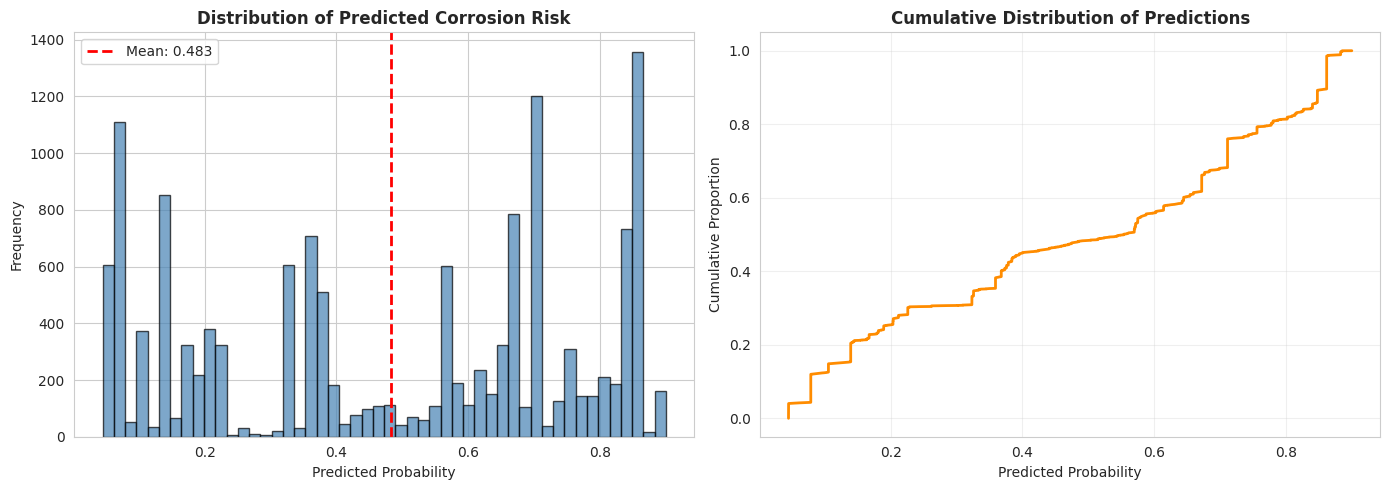

In [36]:
# Visualize prediction distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(y_pred_proba, bins=50, alpha=0.7, edgecolor='black', color='steelblue')
axes[0].set_title('Distribution of Predicted Corrosion Risk', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Frequency')
axes[0].axvline(y_pred_proba.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {y_pred_proba.mean():.3f}')
axes[0].legend()

# Cumulative distribution
sorted_probs = np.sort(y_pred_proba)
cumulative = np.arange(1, len(sorted_probs) + 1) / len(sorted_probs)
axes[1].plot(sorted_probs, cumulative, linewidth=2, color='darkorange')
axes[1].set_title('Cumulative Distribution of Predictions', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Cumulative Proportion')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
# Save submission file
submission_df.to_csv('submission.csv', index=False)

print("✓ Submission file saved as 'submission.csv'")
print(f"\nSubmission format:")
print(submission_df.head())
print(f"\nLast predictions:")
print(submission_df.tail())

# Download file (for Colab)
files.download('submission.csv')

✓ Submission file saved as 'submission.csv'

Submission format:
               id  corrosion_risk
0  022433_2020-11        0.044926
1  022433_2020-12        0.078749
2  022433_2021-01        0.139355
3  022433_2021-02        0.078749
4  022433_2021-03        0.078749

Last predictions:
                   id  corrosion_risk
14298  fd589c_2025-04        0.861860
14299  fd589c_2025-05        0.861860
14300  fd589c_2025-06        0.858746
14301  fd589c_2025-07        0.861860
14302  fd589c_2025-08        0.861860


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("="*60)
print("INFERENCE COMPLETE")
print("="*60)
print(f"\n✓ Test aircraft processed: {len(submission_df)}")
print(f"✓ Predictions generated using reference month: {reference_month_test:.0f}")
print(f"✓ Model: {'TabPFN' if use_tabpfn else 'GradientBoosting'} with isotonic calibration")
print(f"\n✓ Submission file: submission.csv")
print(f"  - Format: aircraft_id, corrosion_risk")
print(f"  - Rows: {len(submission_df)}")
print(f"\n✓ Prediction range: [{y_pred_proba.min():.4f}, {y_pred_proba.max():.4f}]")
print(f"✓ Mean prediction: {y_pred_proba.mean():.4f}")
print("="*60)